In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S071_001_00000012.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S082_001_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S116_001_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S097_001_00000020.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S085_003_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S127_001_00000015.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S085_003_00000011.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S107_001_00000008.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S138_004_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S068_003_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S126_004_00000010.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S068_003_00000014.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surp

In [2]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
import os, cv2, numpy as np

ck_data = []
ck_labels = []

ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

emotion_names = sorted(os.listdir(ck_path))  

for label, emotion in enumerate(emotion_names):
    emotion_path = os.path.join(ck_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
            
        img = cv2.resize(img, (48,48))

        ck_data.append(img)
        ck_labels.append(label)

ck_data = np.array(ck_data)
ck_labels = np.array(ck_labels)

print("CK+:", ck_data.shape)
print("Labels:", np.unique(ck_labels))

CK+: (981, 48, 48)
Labels: [0 1 2 3 4 5 6]


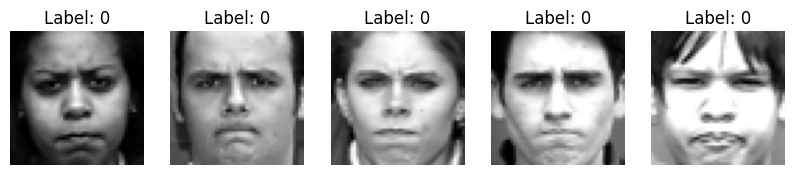

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(ck_data[i], cmap='gray')
    plt.title(f"Label: {ck_labels[i]}")
    plt.axis('off')

plt.show()

In [5]:
from skimage.feature import hog

def extract_hog(images):
    return np.array([
        hog(img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2))
        for img in images
    ])

X_ck_hog = extract_hog(ck_data)

print("CK+ HOG:", X_ck_hog.shape)

CK+ HOG: (981, 900)


In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ck_hog,
    ck_labels,
    test_size=0.3,
    random_state=42,
    stratify=ck_labels
)

print(X_train.shape, X_test.shape)

(686, 900) (295, 900)


In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [10]:
acc_ck_hog = accuracy_score(y_test, y_pred)

print("CK+ HOG Accuracy:", acc_ck_hog)

CK+ HOG Accuracy: 0.9898305084745763


In [11]:
emotion_names = sorted(os.listdir(ck_path))

print(classification_report(
    y_test,
    y_pred,
    target_names=emotion_names
))

              precision    recall  f1-score   support

       anger       0.98      0.98      0.98        41
    contempt       1.00      1.00      1.00        16
     disgust       0.98      1.00      0.99        53
        fear       1.00      0.96      0.98        23
       happy       0.98      1.00      0.99        62
     sadness       1.00      0.96      0.98        25
    surprise       1.00      1.00      1.00        75

    accuracy                           0.99       295
   macro avg       0.99      0.98      0.99       295
weighted avg       0.99      0.99      0.99       295



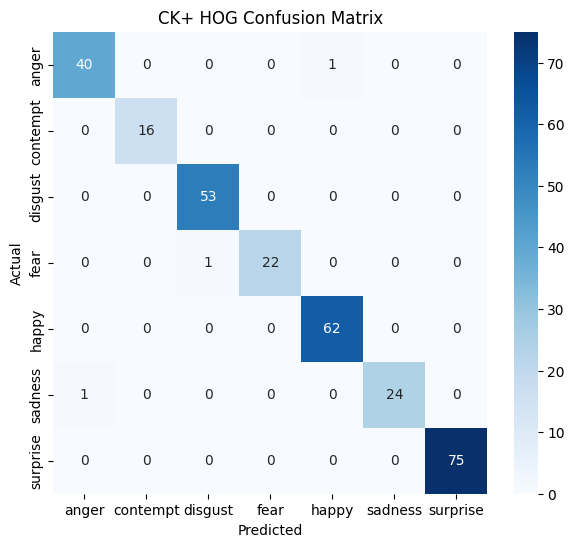

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("CK+ HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

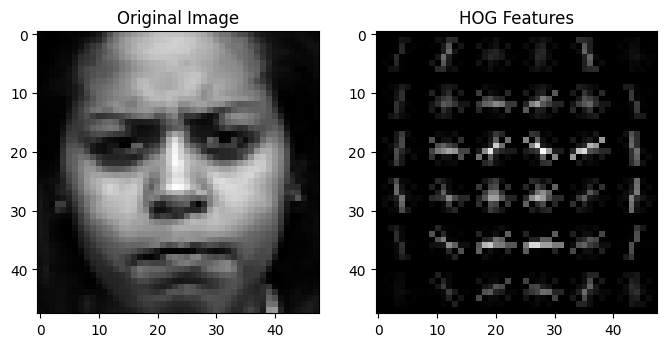

In [13]:
sample_img = ck_data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")

plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X_ck_hog,
    ck_labels,
    cv=5
)

print("5-Fold Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


5-Fold Scores: [0.97461929 0.98979592 1.         1.         0.98469388]
Mean Accuracy: 0.9898218170516937
Std Dev: 0.009639544588252384


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


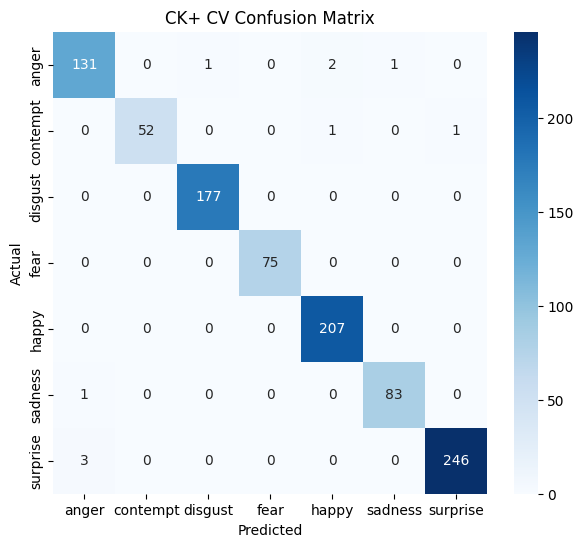

In [15]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    pipeline,
    X_ck_hog,
    ck_labels,
    cv=5
)

cm_cv = confusion_matrix(ck_labels, y_pred_cv)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_cv,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("CK+ CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# MobileNetV2
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

# VGG16
vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("Models Loaded")

2026-05-10 05:46:32.041102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778391992.230623      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778391992.286484      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778391992.719374      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778391992.719414      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778391992.719417      23 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Models Loaded


In [17]:
def extract_mobilenet_features(images, model):

    features = []

    for img in images:

        img = cv2.resize(img, (224,224))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = preprocess_input(img)

        img = np.expand_dims(img, axis=0)

        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [18]:
def extract_vgg_features(images, model):

    features = []

    for img in images:

        img = cv2.resize(img, (224,224))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = vgg_preprocess(img)

        img = np.expand_dims(img, axis=0)

        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [19]:
X_ck_cnn = extract_mobilenet_features(ck_data, mobilenet)

print("MobileNet Features:", X_ck_cnn.shape)

I0000 00:00:1778392020.041640      75 service.cc:152] XLA service 0x79fe28003380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778392020.041694      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778392020.041702      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778392020.661733      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 05:47:08.917541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 05:47:09.076422: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 05:47:09.210673: E external/local_xl

MobileNet Features: (981, 1280)


In [20]:
X_ck_vgg = extract_vgg_features(ck_data, vgg)

print("VGG Features:", X_ck_vgg.shape)

VGG Features: (981, 512)


In [21]:
X_ck_hybrid = np.concatenate(
    [X_ck_cnn, X_ck_vgg],
    axis=1
)

print("Hybrid Shape:", X_ck_hybrid.shape)

Hybrid Shape: (981, 1792)


In [22]:
X_ck_hog_cnn = np.concatenate(
    [X_ck_hog, X_ck_cnn],
    axis=1
)

print("HOG + MobileNet:", X_ck_hog_cnn.shape)

HOG + MobileNet: (981, 2180)


In [23]:
X_ck_hog_vgg = np.concatenate(
    [X_ck_hog, X_ck_vgg],
    axis=1
)

print("HOG + VGG:", X_ck_hog_vgg.shape)

HOG + VGG: (981, 1412)


In [24]:
X_ck_final = np.concatenate(
    [X_ck_hog, X_ck_hybrid],
    axis=1
)

print("HOG + Hybrid:", X_ck_final.shape)

HOG + Hybrid: (981, 2692)


In [25]:
from sklearn.metrics import accuracy_score

def run_model(X, labels, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=0.3,
        random_state=42,
        stratify=labels
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy:", acc)

    return acc, y_test, y_pred

In [26]:
acc_hog, _, _ = run_model(
    X_ck_hog,
    ck_labels,
    "HOG"
)

acc_cnn, _, _ = run_model(
    X_ck_cnn,
    ck_labels,
    "MobileNet"
)

acc_vgg, _, _ = run_model(
    X_ck_vgg,
    ck_labels,
    "VGG16"
)

acc_hybrid, _, _ = run_model(
    X_ck_hybrid,
    ck_labels,
    "Hybrid CNN"
)

acc_hog_cnn, _, _ = run_model(
    X_ck_hog_cnn,
    ck_labels,
    "HOG + MobileNet"
)

acc_hog_vgg, _, _ = run_model(
    X_ck_hog_vgg,
    ck_labels,
    "HOG + VGG"
)

acc_final, _, _ = run_model(
    X_ck_final,
    ck_labels,
    "HOG + Hybrid"
)

HOG Accuracy: 0.9898305084745763
MobileNet Accuracy: 0.9966101694915255


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


VGG16 Accuracy: 0.9966101694915255
Hybrid CNN Accuracy: 1.0
HOG + MobileNet Accuracy: 1.0
HOG + VGG Accuracy: 0.9966101694915255
HOG + Hybrid Accuracy: 1.0


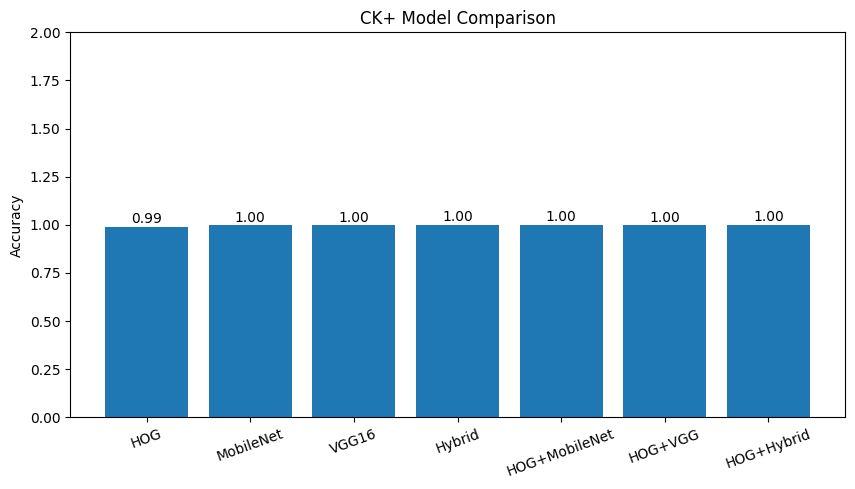

In [27]:
models = [
    'HOG',
    'MobileNet',
    'VGG16',
    'Hybrid',
    'HOG+MobileNet',
    'HOG+VGG',
    'HOG+Hybrid'
]

scores = [
    acc_hog,
    acc_cnn,
    acc_vgg,
    acc_hybrid,
    acc_hog_cnn,
    acc_hog_vgg,
    acc_final
]

plt.figure(figsize=(10,5))

bars = plt.bar(models, scores)

plt.ylim(0,2)

plt.title("CK+ Model Comparison")
plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.xticks(rotation=20)

plt.show()

In [28]:
cv_hog_hybrid = cross_val_score(
    pipeline,
    X_ck_final,
    ck_labels,
    cv=5
)

cv_hybrid = cross_val_score(
    pipeline,
    X_ck_hybrid,
    ck_labels,
    cv=5
)

cv_hog_vgg = cross_val_score(
    pipeline,
    X_ck_hog_vgg,
    ck_labels,
    cv=5
)

print("HOG+Hybrid Mean:", cv_hog_hybrid.mean())
print("Hybrid Mean:", cv_hybrid.mean())
print("HOG+VGG Mean:", cv_hog_vgg.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


HOG+Hybrid Mean: 0.9938930902310164
Hybrid Mean: 0.9908318657412204
HOG+VGG Mean: 0.9928726820677509


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


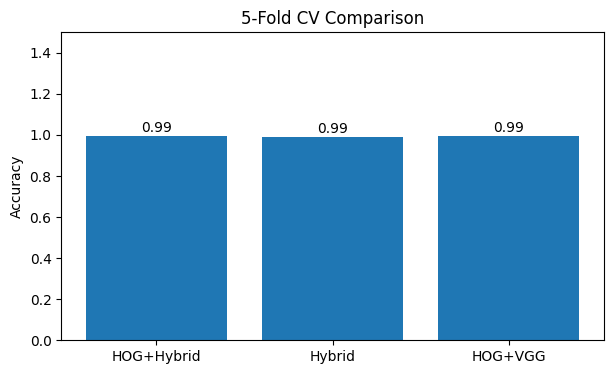

In [29]:
models = ['HOG+Hybrid', 'Hybrid', 'HOG+VGG']

means = [
    cv_hog_hybrid.mean(),
    cv_hybrid.mean(),
    cv_hog_vgg.mean()
]

plt.figure(figsize=(7,4))

bars = plt.bar(models, means)

plt.ylim(0,1.5)

plt.title("5-Fold CV Comparison")
plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()